# Case Study 1: Hospital Readmission Prediction

## Objective
Predict whether a patient will be readmitted to the hospital within 30 days using Logistic Regression with L2 regularization.

## Evaluation
The model is evaluated using ROC-AUC, confusion matrix, precision, recall, and F1-score. The clinical cost of false negatives and false positives is also discussed.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [21]:
uploaded = files.upload()

Saving hospital_readmissions_30k.csv to hospital_readmissions_30k (2).csv


In [37]:
df = pd.read_csv("hospital_readmissions_30k.csv")

df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [38]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["readmitted_30_days"].value_counts())

Dataset shape: (30000, 12)

Missing values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Target distribution:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [39]:
df = df.drop("patient_id", axis=1)

In [40]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

In [41]:
X = pd.get_dummies(X, drop_first=True)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=2000,
    class_weight="balanced"
)

In [47]:
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [48]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [49]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.5230


In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

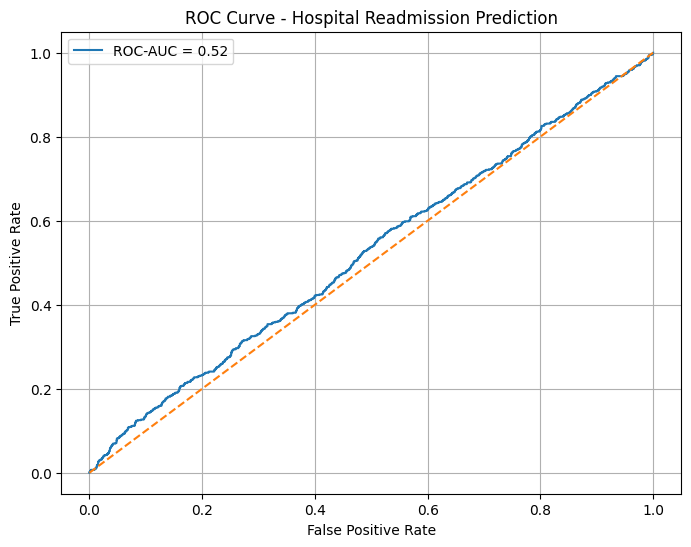

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
y_pred = model.predict(X_test_scaled)

In [53]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5552

Confusion Matrix:
[[2999 2266]
 [ 403  332]]

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.57      0.69      5265
         Yes       0.13      0.45      0.20       735

    accuracy                           0.56      6000
   macro avg       0.50      0.51      0.45      6000
weighted avg       0.79      0.56      0.63      6000



## Clinical Cost of False Negatives vs False Positives

A false negative occurs when the model predicts that a patient will not be readmitted, but the patient is actually readmitted within 30 days. This can be clinically important because a high-risk patient may not receive additional monitoring, follow-up, or preventive care.

A false positive occurs when the model predicts that a patient will be readmitted, but the patient is not actually readmitted. This can result in unnecessary follow-up, additional monitoring, and increased healthcare resource usage.

In this application, false negatives can have significant clinical consequences because failing to identify a high-risk patient may result in missed opportunities for intervention. However, reducing false negatives can increase false positives and therefore increase healthcare resource usage.

Therefore, the classification threshold should be selected according to the relative clinical and operational costs of these two types of errors. ROC-AUC is useful for evaluating the model's overall discrimination, while recall and precision provide additional information about the model's behavior for the readmitted class.